In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Packages and libraries needed for main function calls 
import import_ipynb
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from utils import (
    load_images_and_masks,
    view_data,
    preprocess_images_and_masks,
)
from unet import unet_model, test_unet, plot_losses
# from folder_config import TRAINING_DIR, BASE_DIR
# Note: You can comment/uncomment the line below if you are seeing several unnecessary/annoying warnings from tensorflow.
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from tensorflow.keras import callbacks
import tensorflow as tf

In [6]:
# Set the necessary directories. These should be relative to the working directory
images_dir = "Datasets/Pala_Mesa_Roads_Rails/images"  # Directory for images
masks_dir = "Datasets/Pala_Mesa_Roads_Rails/labels"  # Directory for masks
model_dir = "models"  # Directory for saving the model
model_name = "trained_UNet_Pala_Mesa.keras"  # Model file name

In [7]:
# Load the images and masks
images, masks, missing_masks, names_map = load_images_and_masks(
    images_dir,          # Directory containing the images
    masks_dir,           # Directory containing the masks
    file_ext="tif",      # File extension of the images and masks
    max_count=250,      # Maximum number of images and masks to load
    trim_names=True      # Whether to trim the names of the files
)

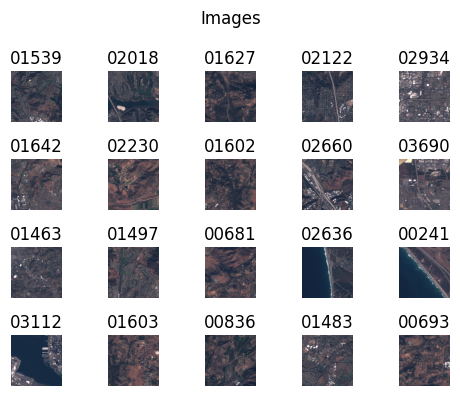

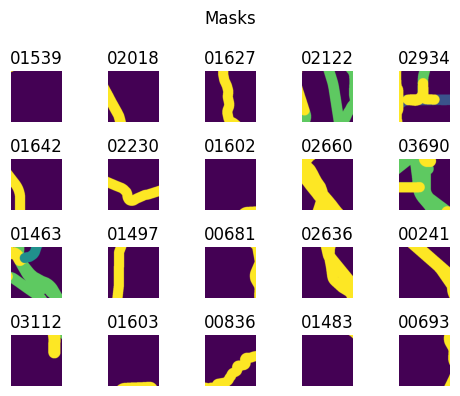

In [8]:
# View images 
view_data(images=images, max_plots=20, max_cols=5, randomize=False, colors=True)

# View masks
view_data(masks=masks, max_plots=20, max_cols=5, randomize=False, colors=True)

In [9]:
# Load images and masks for second dataset
images_dir2 = "/home/grant04/28746281/Z1_Roads_Thomas/images"
masks_dir2 = "/home/grant04/28746281/Z1_Roads_Thomas/labels"

images2, masks2, missing_masks2, names_map2 = load_images_and_masks(
    images_dir2,          # Directory containing the images
    masks_dir2,           # Directory containing the masks
    file_ext="tif",      # File extension of the images and masks
    max_count=250,      # Maximum number of images and masks to load
    trim_names=True      # Whether to trim the names of the files
)

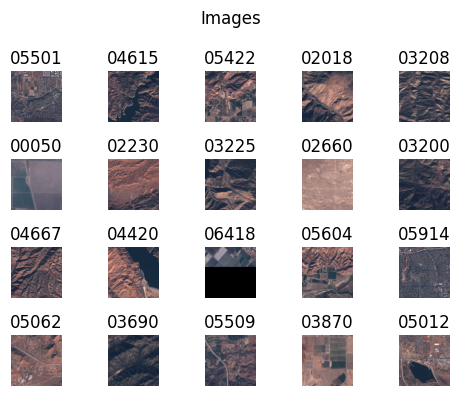

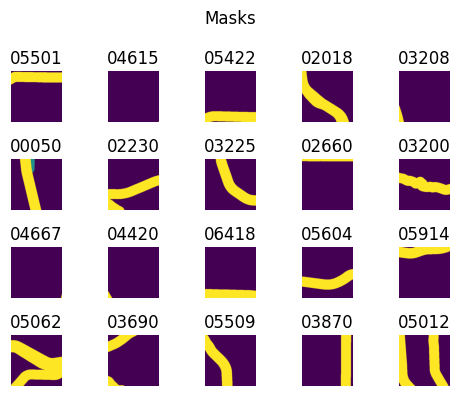

In [10]:
# View images 
view_data(images=images2, max_plots=20, max_cols=5, randomize=False, colors=True)

# View masks
view_data(masks=masks2, max_plots=20, max_cols=5, randomize=False, colors=True)

In [11]:
# Combine both datasets
for key in images2:
    if key in images:
        new_key = f"dataset2_{key}"
    else:
        new_key = key
    images[new_key] = images2[key]

for key in masks2:
    if key in masks:
        new_key = f"dataset2_{key}"
    else:
        new_key = key
    masks[new_key] = masks2[key]

In [12]:
# Preprocess the data for the U-Net
preprocessed_images, preprocessed_masks, threshold, image_names, num_classes = (
        preprocess_images_and_masks(images, masks, num_classes=4)
    )

# Split the images into validation, training, and testing
images_train, images_test, masks_train, masks_test, train_names, test_names = (
        train_test_split(
            preprocessed_images,
            preprocessed_masks,
            image_names,
            test_size=0.2,
            random_state=42,
        )
    )

I0000 00:00:1777310750.538855  883115 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79191 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:47:00.0, compute capability: 8.0
<string>:69: UserWarning: Detected 5 classes, which is larger than the input 4 classes.
You must have at least the the number of possible classes, in this case 5, with the following classes: [0, 1, 2, 3, 4]


Preprocessed data information:
Number of images: 500.
Shape of images dataset: (500, 256, 256, 3).
Images type: float32.
Number of masks: 500.
Shape of masks dataset: (500, 256, 256, 5).
Masks type: float32.
Number of classes: 5.


In [13]:
# Create the U-Net model and assign training settings
model = unet_model(input_shape=(256, 256, 3), num_classes=num_classes, num_blocks=4)
model.summary()

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
checkpoint = callbacks.ModelCheckpoint(
    model_name, save_best_only=True, monitor="val_loss"
)
callbacks=[early_stop, checkpoint]

epochs = 25
batch_size = 3
model_verbosity = 1

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,379,205 (119.70 MB)

 Trainable params: 31,379,205 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train the model
model_fit = model.fit(
    images_train,
    masks_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(images_test, masks_test),
    callbacks=callbacks,
    verbose=model_verbosity,
)

Epoch 1/25


I0000 00:00:1777310816.481764  888501 service.cc:152] XLA service 0x15541400ad80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777310816.481792  888501 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-80GB, Compute Capability 8.0
2026-04-27 13:26:57.006582: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777310818.346936  888501 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/134 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5221 - loss: 78.1057

I0000 00:00:1777310833.652427  888501 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


134/134 ━━━━━━━━━━━━━━━━━━━━ 38s 127ms/step - accuracy: 0.7903 - loss: 4.5446 - val_accuracy: 0.8244 - val_loss: 0.6987
Epoch 2/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.7959 - loss: 0.7684 - val_accuracy: 0.8244 - val_loss: 0.6704
Epoch 3/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7959 - loss: 0.7552 - val_accuracy: 0.8244 - val_loss: 0.7035
Epoch 4/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.7959 - loss: 0.7511 - val_accuracy: 0.8244 - val_loss: 0.6647
Epoch 5/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.7959 - loss: 0.7464 - val_accuracy: 0.8244 - val_loss: 0.6618
Epoch 6/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7959 - loss: 0.7452 - val_accuracy: 0.8244 - val_loss: 0.6624
Epoch 7/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7959 - loss: 0.7411 - val_accuracy: 0.8244 - val_loss: 0.6549
Epoch 8/25
134/134 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7921 - loss: 0.7408 - val_accuracy: 0.

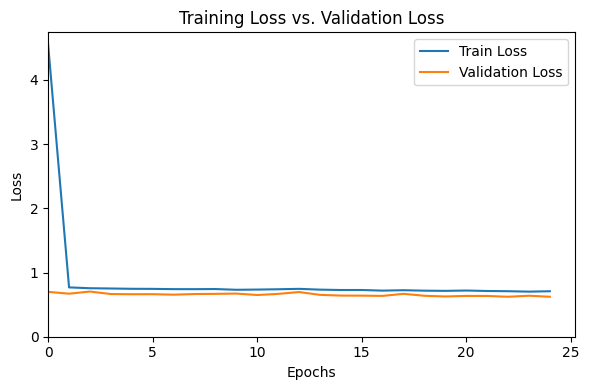

In [15]:
# View model losses
plot_losses(model_fit)

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 334ms/step
Metrics based on test data:

Class 0 Individual Metrics:
Precision: 0.7958910369873047
Recall: 1.0
F1 Score: 0.8863466887417077

Class 1 Individual Metrics:
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Class 2 Individual Metrics:
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Class 3 Individual Metrics:
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Class 4 Individual Metrics:
Precision: 0.0
Recall: 0.0
F1 Score: 0.0



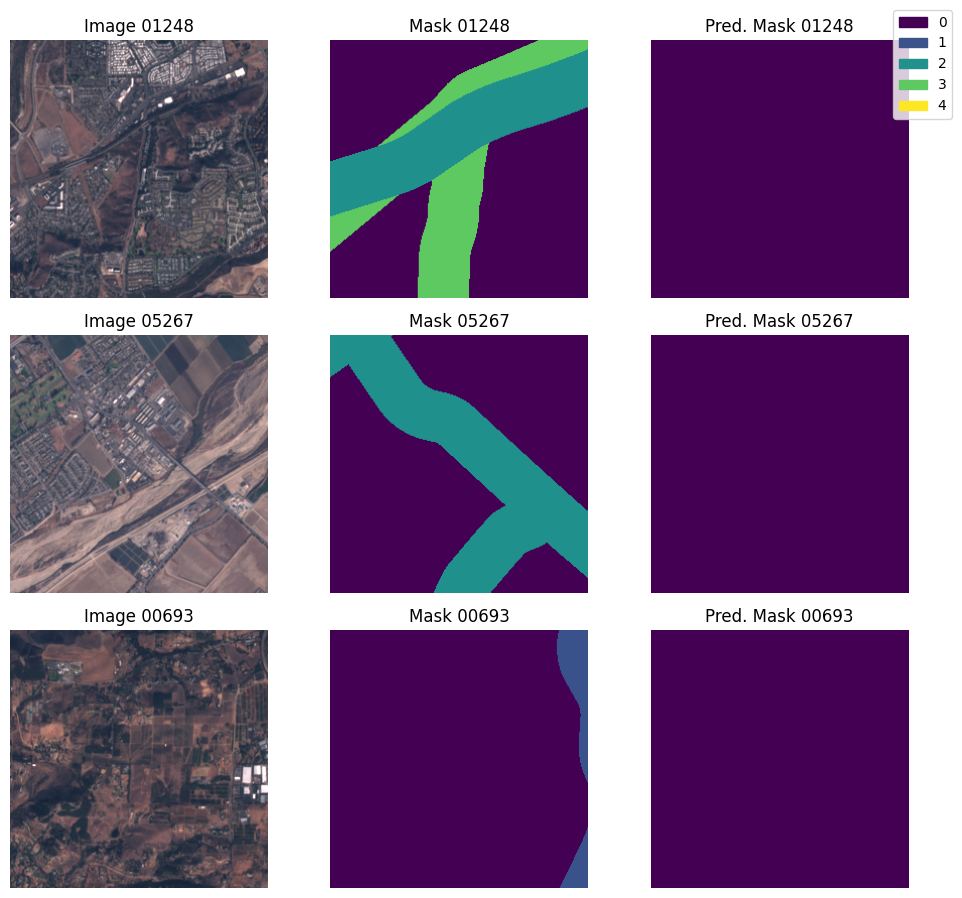

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [16]:
# Test the model
test_unet(
    model,
    images_train,
    masks_train,
    num_classes,
    threshold=threshold,
    image_names=train_names,
    display_count=3,
)